In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import pandas as pd

# Downloading dataset
(train_images, train_labels), (test_images, test_labels) = datasets.cifar100.load_data()

train_images, test_images = train_images / 255.0, test_images / 255.0

print(f"Training data shape: {train_images.shape}") 
print(f"Test data shape: {test_images.shape}")     

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 136s 1us/step


C:\Users\Insomnyac\anaconda3\envs\ml-lab\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Training data shape: (50000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)


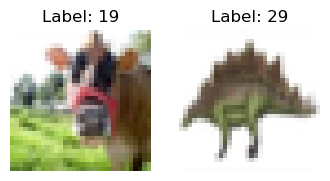

In [2]:
# Displaying 2 images
plt.figure(figsize=(4, 2))
for i in range(2):
    plt.subplot(1, 2, i + 1)
    plt.imshow(train_images[i])
    plt.title(f"Label: {train_labels[i][0]}")
    plt.axis('off')
plt.show()

In [7]:
# Creating fully connected network
model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Flatten(),                      # Flatten 32*32*3 into 3,072 pixels
    layers.Dense(1024, activation='relu'), # First hidden layer
    layers.Dense(512, activation='relu'),  # Second hidden layer
    layers.Dense(256, activation='relu'),  # Third hidden layer
    layers.Dense(100, activation='softmax')# Output layer for 100 classes
])

model.compile(optimizer='sgd',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)                  │ (None, 3072)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1024)                │       3,146,752 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 512)                 │         524,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 100)                 │          25,700 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,828,580 (14.60 MB)

 Trainable params: 3,828,580 (14.60 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.0643 - loss: 4.2335 - val_accuracy: 0.0963 - val_loss: 3.9759
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.1203 - loss: 3.8253 - val_accuracy: 0.1373 - val_loss: 3.7426
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.1503 - loss: 3.6602 - val_accuracy: 0.1492 - val_loss: 3.6664
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.1691 - loss: 3.5532 - val_accuracy: 0.1645 - val_loss: 3.5953
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.1852 - loss: 3.4630 - val_accuracy: 0.1807 - val_loss: 3.4968
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.1988 - loss: 3.3813 - val_accuracy: 0.1825 - val_loss: 3.4801
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.2124 - loss: 3.3146 - val_accuracy: 0.1875 - val_loss: 3.4635
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.2232 - l

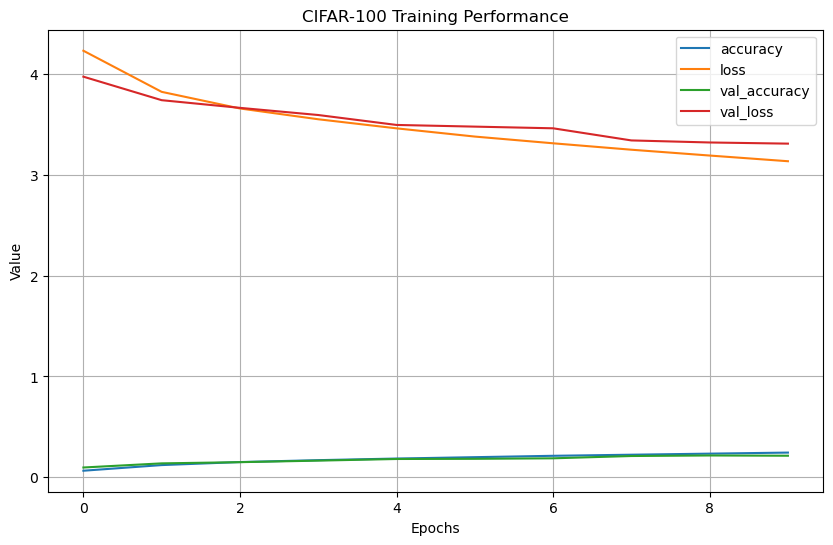

313/313 - 2s - 5ms/step - accuracy: 0.2131 - loss: 3.3113

Final Test Accuracy: 0.2131


In [8]:
history = model.fit(train_images, train_labels, epochs=10, 
                    validation_data=(test_images, test_labels), verbose=1)

pd.DataFrame(history.history).plot(figsize=(10, 6))
plt.grid(True)
plt.title("CIFAR-100 Training Performance")
plt.xlabel("Epochs")
plt.ylabel("Value")
plt.show()

# Evaluating performance
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f"\nFinal Test Accuracy: {test_acc:.4f}")

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.2532 - loss: 3.0877 - val_accuracy: 0.2230 - val_loss: 3.2717
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - accuracy: 0.2635 - loss: 3.0351 - val_accuracy: 0.2214 - val_loss: 3.2718
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.2730 - loss: 2.9876 - val_accuracy: 0.2348 - val_loss: 3.2058
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.2787 - loss: 2.9411 - val_accuracy: 0.2453 - val_loss: 3.1777
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.2889 - loss: 2.9004 - val_accuracy: 0.2420 - val_loss: 3.1896
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.2978 - loss: 2.8533 - val_accuracy: 0.2412 - val_loss: 3.2087
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.3048 - loss: 2.8091 - val_accuracy: 0.2347 - val_loss: 3.2058
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.3144 -

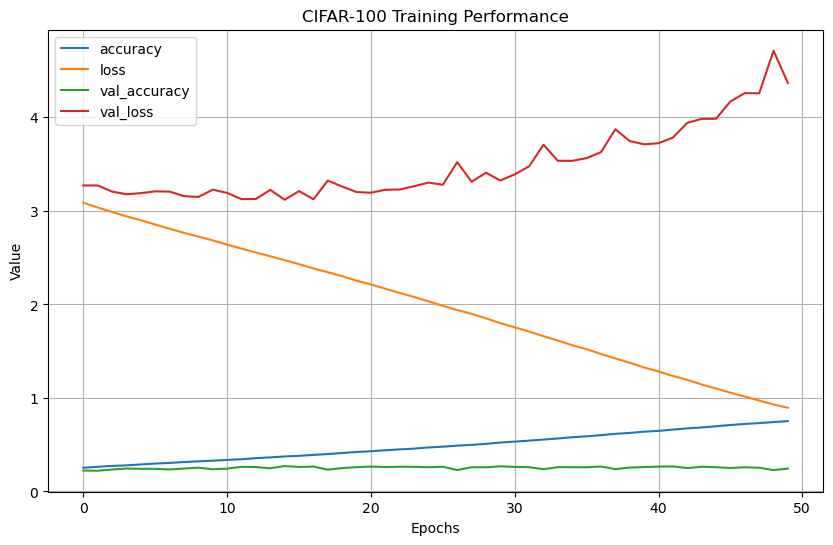

313/313 - 2s - 6ms/step - accuracy: 0.2442 - loss: 4.3670

Final Test Accuracy: 0.2442


In [9]:
history = model.fit(train_images, train_labels, epochs=50, 
                    validation_data=(test_images, test_labels), verbose=1)

pd.DataFrame(history.history).plot(figsize=(10, 6))
plt.grid(True)
plt.title("CIFAR-100 Training Performance")
plt.xlabel("Epochs")
plt.ylabel("Value")
plt.show()

# Evaluating performance
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f"\nFinal Test Accuracy: {test_acc:.4f}")

In [11]:
# Conclusion
# Moving from 10 to 50 epochs only gained about 4% accuracy. This confirms that the bottleneck isn't epochs; it is the architecture. A fully connected network simply cannot see the 3D structures in color images effectively.